# UTS AI for Data Scientist (Klasifikasi Jenis Sampah (Organic, Recyclable, Non-Recyclable))
- Nama  : Fahma Zuaf Zarir
- NIM   : 23611054 

## Pengumpulan dan Persiapan Data

### Import Package

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (

    Dense,
    Flatten,
    Dropout,

    Conv2D,
    MaxPooling2D,

    BatchNormalization
)

from tensorflow.keras.preprocessing.image import (

    ImageDataGenerator,
    load_img,
    img_to_array
)

from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (

    confusion_matrix,
    classification_report
)


Pada tahap ini dilakukan import beberapa library yang digunakan untuk membuat model klasifikasi gambar. Library yang digunakan membantu proses pengolahan data, pembuatan model ANN dan CNN, visualisasi hasil, preprocessing gambar, serta evaluasi performa model.

In [ ]:
# Rename file
dataset_path = "Dataset2"

# Nama folder
classes = [

    "Organic",

    "Non_Recyclable",

    "Recyclable"
]

# =========================================================
# RENAME FILE
# =========================================================

for cls in classes:

    folder_path = os.path.join(
        dataset_path,
        cls
    )

    files = os.listdir(folder_path)

    # Urutkan file
    files.sort()

    print(f"\nProcessing {cls}...")

    for i, file_name in enumerate(files):

        # Ambil ekstensi
        file_ext = os.path.splitext(file_name)[1]

        # =================================================
        # BUAT PREFIX NAMA FILE
        # =================================================

        if cls == "Organic":

            prefix = "organic"

        elif cls == "Non_Recyclable":

            prefix = "nonrecyclable"

        else:

            prefix = "recyclable"

        # =================================================
        # NAMA BARU
        # =================================================

        new_name = f"{prefix}_{i+1:03d}{file_ext}"

        # Path lama
        old_path = os.path.join(
            folder_path,
            file_name
        )

        # Path baru
        new_path = os.path.join(
            folder_path,
            new_name
        )

        # Rename
        os.rename(old_path, new_path)

    print(f"{cls} selesai di-rename!")

print("\nSemua file berhasil di-rename!")

Syntax ini digunakan untuk merename file gambar dalam folder dataset. Setiap gambar akan diberi nama baru dengan format yang konsisten, seperti "organic_001.jpg", "nonrecyclable_001.jpg", dan "recyclable_001.jpg". Hal ini memudahkan dalam pengelolaan data dan memastikan bahwa setiap gambar memiliki nama yang unik dan mudah diidentifikasi berdasarkan kelasnya.

### Split Data

In [ ]:
# Folder dataset awal
source_dir = "Dataset2"

# Folder hasil split
output_dir = "processed_dataset2"

# Rasio pembagian data
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

# Nama kelas
classes = ["Organic", "Recyclable", "Non_Recyclable"]

# Membuat folder train, validation, test
for split in ["train", "validation", "test"]:

    for cls in classes:

        os.makedirs(
            os.path.join(output_dir, split, cls),
            exist_ok=True
        )

# Proses split dataset
for cls in classes:

    class_dir = os.path.join(source_dir, cls)

    images = os.listdir(class_dir)

    # Acak gambar
    random.shuffle(images)

    total = len(images)

    # Hitung jumlah data
    train_count = int(total * train_ratio)
    val_count = int(total * val_ratio)

    # Membagi data
    train_images = images[:train_count]

    val_images = images[
        train_count : train_count + val_count
    ]

    test_images = images[
        train_count + val_count :
    ]

    # Function copy file
    def copy_files(file_list, split_name):

        for file in file_list:

            src_path = os.path.join(class_dir, file)

            dst_path = os.path.join(
                output_dir,
                split_name,
                cls,
                file
            )

            shutil.copy(src_path, dst_path)

    # Copy file
    copy_files(train_images, "train")
    copy_files(val_images, "validation")
    copy_files(test_images, "test")

    print(f"{cls} selesai diproses!")

print("\nSplit dataset selesai!")

Syntax ini digunakan untuk split dataset menjadi train, validation, dan test dengan rasio 70:15:15. Pastikan untuk menyesuaikan nama folder dan path sesuai dengan struktur direktori.

### Preprocessing

In [2]:
train_dir = "processed_dataset2/train"

validation_dir = "processed_dataset2/validation"

test_dir = "processed_dataset2/test"

In [3]:
IMG_SIZE = (224,224)

BATCH_SIZE = 32

# =========================================================
# PREPROCESSING
# =========================================================

train_datagen = ImageDataGenerator(

    # NORMALISASI
    rescale=1./255,

    # AUGMENTASI
    rotation_range=20,

    zoom_range=0.2,

    width_shift_range=0.1,

    height_shift_range=0.1,

    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(

    rescale=1./255
)


Syntax diatas digunakan untuk melakukan preprocessing pada dataset gambar. Pada bagian `train_datagen`, dilakukan normalisasi dengan `rescale=1./255` untuk mengubah nilai piksel dari rentang [0, 255] menjadi [0, 1]. Selain itu, dilakukan augmentasi data dengan berbagai transformasi seperti rotasi, zoom, pergeseran horizontal dan vertikal, serta pembalikan horizontal untuk meningkatkan variasi data pelatihan.

### Load Dataset

Found 420 images belonging to 3 classes.
Found 90 images belonging to 3 classes.
Found 90 images belonging to 3 classes.


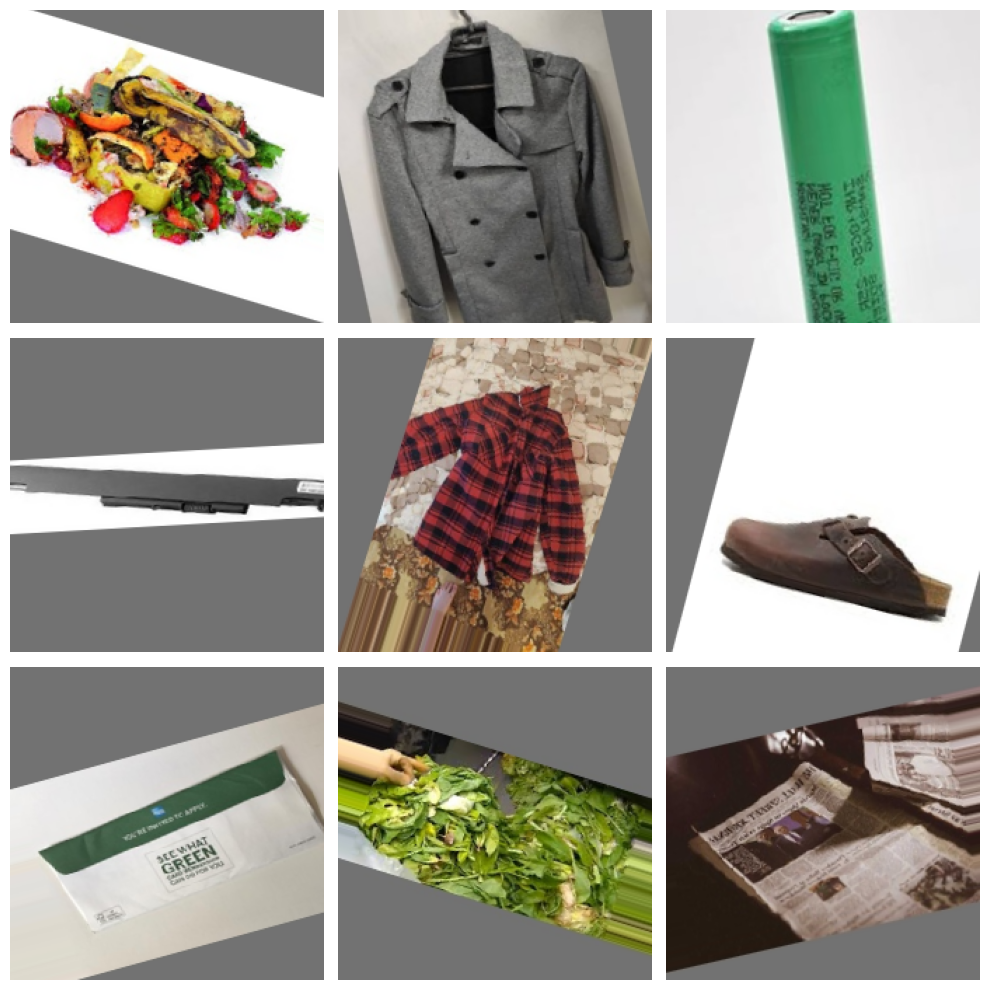

In [4]:
# =========================================================
# LOAD TRAIN DATA
# =========================================================

train_generator = train_datagen.flow_from_directory(

    directory=train_dir,

    target_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    class_mode='categorical'
)

# =========================================================
# LOAD VALIDATION DATA
# =========================================================

validation_generator = val_test_datagen.flow_from_directory(

    directory=validation_dir,

    target_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    class_mode='categorical'
)

# =========================================================
# LOAD TEST DATA
# =========================================================

test_generator = val_test_datagen.flow_from_directory(

    directory=test_dir,

    target_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    class_mode='categorical',

    shuffle=False
)

# =========================================================
# VISUALISASI DATA
# =========================================================

images, labels = next(train_generator)

plt.figure(figsize=(10,10))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(images[i])

    plt.axis("off")

plt.tight_layout()

plt.show()


Pada syntax ini digunakan untuk menampilkan 9 gambar pertama dari data training yang telah diproses dengan augmentasi. Gambar-gambar ini diambil dari batch pertama yang dihasilkan oleh `train_generator`. Setiap gambar ditampilkan dalam subplot 3x3, dan axis dinonaktifkan untuk memperjelas tampilan gambar.

## ANN

In [5]:
# =========================================================
# ANN GENERATOR
# =========================================================

ann_train_generator = train_datagen.flow_from_directory(

    directory=train_dir,

    target_size=(64,64),

    batch_size=32,

    class_mode='categorical'
)

ann_validation_generator = val_test_datagen.flow_from_directory(

    directory=validation_dir,

    target_size=(64,64),

    batch_size=32,

    class_mode='categorical'
)

ann_test_generator = val_test_datagen.flow_from_directory(

    directory=test_dir,

    target_size=(64,64),

    batch_size=32,

    class_mode='categorical',

    shuffle=False
)

Found 420 images belonging to 3 classes.
Found 90 images belonging to 3 classes.
Found 90 images belonging to 3 classes.


Pada syntax ANN generator digunakan ukuran gambar yang lebih kecil (64x64) untuk mempercepat proses pelatihan model ANN, karena model ANN biasanya tidak memerlukan informasi spasial yang kompleks seperti pada CNN.

In [6]:
ann_model = Sequential([

    Flatten(
        input_shape=(64,64,3)
    ),

    Dense(
        256,
        activation='relu'
    ),

    Dropout(0.3),

    Dense(
        64,
        activation='relu'
    ),

    Dropout(0.3),

    Dense(
        3,
        activation='softmax'
    )
])

# =========================================================
# COMPILE ANN
# =========================================================

ann_model.compile(

    optimizer='adam',

    loss='categorical_crossentropy',

    metrics=['accuracy']
)

# =========================================================
# SUMMARY ANN
# =========================================================

ann_model.summary()


c:\Users\LENOVO\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     3,145,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,162,627 (12.06 MB)

 Trainable params: 3,162,627 (12.06 MB)

 Non-trainable params: 0 (0.00 B)

Pada output di atas terlihat bahwa model ANN memiliki beberapa layer, yaitu Flatten, Dense, dan Dropout. Layer Flatten digunakan untuk mengubah data gambar berukuran 64×64×3 menjadi bentuk vektor 1 dimensi dengan panjang 12288. Setelah itu, data diproses oleh layer Dense dengan 256 neuron sehingga menghasilkan jumlah parameter yang cukup besar, yaitu 3.145.984 parameter. Layer berikutnya memiliki parameter yang lebih sedikit karena jumlah neuron yang digunakan lebih kecil. Total parameter pada model ANN adalah 3.162.627 parameter

In [7]:
# =========================================================
# TRAINING MODEL ANN
# =========================================================

history_ann = ann_model.fit(

    ann_train_generator,

    validation_data=ann_validation_generator,

    epochs=20
)

c:\Users\LENOVO\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 142ms/step - accuracy: 0.3185 - loss: 4.6101 - val_accuracy: 0.3333 - val_loss: 1.1410
Epoch 2/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - accuracy: 0.3011 - loss: 2.9358 - val_accuracy: 0.4333 - val_loss: 1.0613
Epoch 3/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - accuracy: 0.3796 - loss: 1.6502 - val_accuracy: 0.3333 - val_loss: 1.1024
Epoch 4/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - accuracy: 0.3420 - loss: 1.3178 - val_accuracy: 0.3333 - val_loss: 1.1010
Epoch 5/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - accuracy: 0.3697 - loss: 1.1830 - val_accuracy: 0.3333 - val_loss: 1.0988
Epoch 6/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - accuracy: 0.3412 - loss: 1.1667 - val_accuracy: 0.3333 - val_loss: 1.0988
Epoch 7/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - accuracy: 0.4355 - loss: 1.1574 - val_accuracy: 0.3444 - val_loss: 1.0978
Epoch 8/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - accuracy: 0.3517 - loss: 1.1226 - val_accuracy: 0.3333 - 

In [8]:
# =========================================================
# EVALUASI MODEL
# =========================================================

ann_loss, ann_accuracy = ann_model.evaluate(
    ann_test_generator
)

print(f"\nTest Accuracy : {ann_accuracy:.4f}")
print(f"Test Loss     : {ann_loss:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.6873 - loss: 1.0270

Test Accuracy : 0.5778
Test Loss     : 1.0349


Dapat dilihat akurasi model ANN kurang baik karena model ANN tidak mampu menangkap fitur spasial pada gambar dengan baik. Model ANN hanya melihat piksel secara individual tanpa mempertimbangkan hubungan antar piksel, sehingga informasi penting yang terkait dengan pola dan struktur dalam gambar bisa hilang. Hal ini menyebabkan model ANN kesulitan dalam membedakan antara kelas-kelas yang memiliki kemiripan visual, sehingga akurasinya menjadi rendah.

In [10]:
# =========================================================
# SAVE MODEL ANN
# =========================================================

ann_model.save("ann_model.keras")

print("Model ANN berhasil disimpan")

Model ANN berhasil disimpan


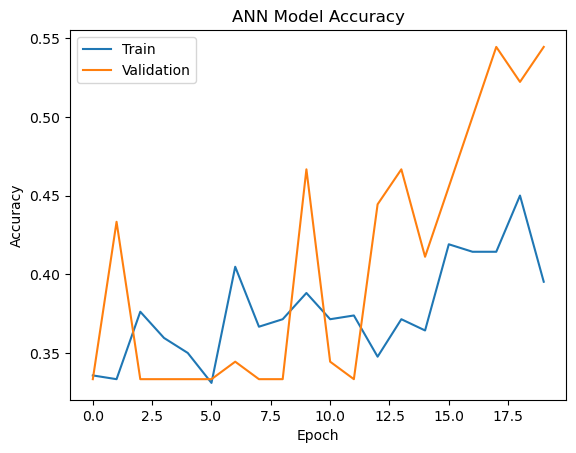

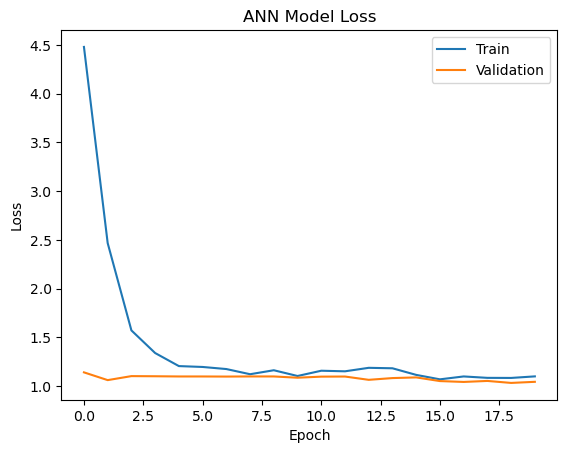

In [11]:
# =========================================================
# GRAFIK ACCURACY
# =========================================================

plt.plot(history_ann.history['accuracy'])
plt.plot(history_ann.history['val_accuracy'])

plt.title('ANN Model Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train', 'Validation'])

plt.show()

# =========================================================
# GRAFIK LOSS
# =========================================================

plt.plot(history_ann.history['loss'])
plt.plot(history_ann.history['val_loss'])

plt.title('ANN Model Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Train', 'Validation'])

plt.show()

Garis biru (akurasi training) terus naik sangat tinggi, yang berarti ANN sangat pintar menghafal gambar yang sudah diajarkan kepadanya. Namun, garis oranye (akurasi validation) justru mendatar di bawah angka 40%. Artinya, saat dites menggunakan gambar sampah yang belum pernah dilihat sebelumnya, model ANN kebingungan dan tebakannya nyaris selalu salah. (Overfitting)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 210ms/step


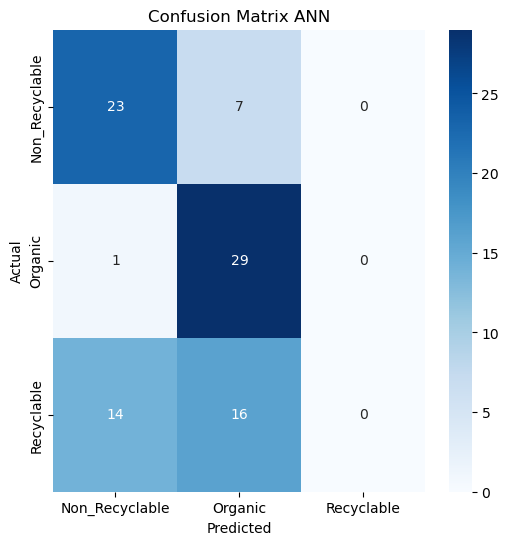


Classification Report:

                precision    recall  f1-score   support

Non_Recyclable       0.61      0.77      0.68        30
       Organic       0.56      0.97      0.71        30
    Recyclable       0.00      0.00      0.00        30

      accuracy                           0.58        90
     macro avg       0.39      0.58      0.46        90
  weighted avg       0.39      0.58      0.46        90



c:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [12]:
# =========================================================
# CONFUSION MATRIX
# =========================================================

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import seaborn as sns

# Prediksi test data
predictions = ann_model.predict(ann_test_generator)

predicted_classes = np.argmax(predictions, axis=1)

true_classes = ann_test_generator.classes

class_labels = list(
    ann_test_generator.class_indices.keys()
)

# Confusion matrix
cm = confusion_matrix(
    true_classes,
    predicted_classes
)

# Visualisasi
plt.figure(figsize=(6,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix ANN")

plt.show()

# Classification report
print("\nClassification Report:\n")

print(
    classification_report(
        true_classes,
        predicted_classes,
        target_names=class_labels
    )
)

Dapat dilihat pada confusion matrix model ANN memiliki performa yang kurang baik dalam mengklasifikasikan kelas "Recyclable". Hal ini terlihat dari banyaknya gambar "Recyclable" yang salah diklasifikasikan sebagai "Organic". Hal ini menunjukkan bahwa model ANN mungkin belum cukup kompleks untuk menangkap fitur-fitur yang membedakan ketiga kelas tersebut dengan baik.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Prediksi ANN : Non-Recyclable


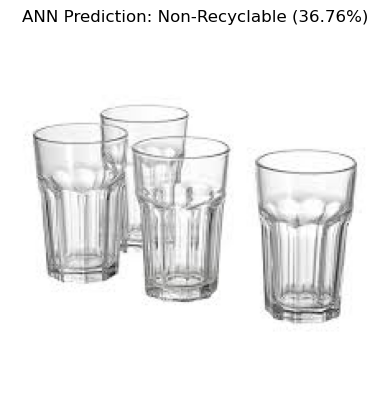

In [27]:
img_path = "gelaskaca.jpg"

# Load image
img = load_img(

    img_path,

    target_size=(64,64)
)

# Image to array
img_array = img_to_array(img)

# Normalisasi
img_array = img_array / 255.0

# Tambah dimensi
img_array = np.expand_dims(
    img_array,
    axis=0
)

# Prediksi
prediction = ann_model.predict(
    img_array
)

# Nama kelas
class_names = [

    "Non-Recyclable",

    "Organic",

    "Recyclable"
]

# Hasil prediksi
predicted_class = class_names[
    np.argmax(prediction)
]

confidence = np.max(prediction) * 100

print("Prediksi ANN :",
      predicted_class)

# Tampilkan gambar
plt.imshow(load_img(img_path))

plt.title(
    f"ANN Prediction: {predicted_class} ({confidence:.2f}%)"
)

plt.axis("off")

plt.show()

Dapat dilihat pada output diatas bahwa gelas kaca terprediksi Non-Recyclable yang dimana gelas kaca merupakan sampah yang Recyclable, maka model ANN kurang dalam menangkap fitur spasial pada gambar dengan baik.

## CNN

In [14]:
cnn_model = Sequential([

    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(224,224,3)
    ),

    MaxPooling2D((2,2)),

    Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D((2,2)),

    Conv2D(
        128,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D((2,2)),

    Flatten(),

    Dense(
        128,
        activation='relu'
    ),

    Dropout(0.5),

    Dense(
        3,
        activation='softmax'
    )
])

# =========================================================
# COMPILE CNN
# =========================================================

cnn_model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),

    loss='categorical_crossentropy',

    metrics=['accuracy']
)

# =========================================================
# SUMMARY CNN
# =========================================================

cnn_model.summary()

c:\Users\LENOVO\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,347 (42.61 MB)

 Trainable params: 11,169,347 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

Dapat dilihat pada syntax di atas bahwa model CNN dibangun menggunakan beberapa layer seperti Conv2D, MaxPooling2D, Flatten, Dense, dan Dropout. Layer Conv2D digunakan untuk mengekstraksi fitur dari gambar, seperti bentuk, tepi, dan pola tertentu. Setelah proses konvolusi, digunakan MaxPooling2D untuk mengurangi ukuran data sehingga proses komputasi menjadi lebih ringan dan model dapat lebih fokus pada fitur penting.

Pada layer konvolusi pertama digunakan 32 filter dan menghasilkan output berukuran (222, 222, 32) dengan jumlah parameter sebanyak 896. Layer konvolusi kedua menggunakan 64 filter dengan jumlah parameter 18.496, sedangkan layer ketiga menggunakan 128 filter dengan jumlah parameter 73.856. Semakin banyak filter yang digunakan, maka semakin banyak fitur gambar yang dapat dipelajari oleh model.

Setelah proses ekstraksi fitur selesai, data diubah menjadi bentuk 1 dimensi menggunakan layer Flatten dengan ukuran output sebesar 86.528. Data kemudian diproses pada layer Dense dengan 128 neuron yang memiliki parameter cukup besar, yaitu 11.075.712 parameter. Layer Dropout digunakan untuk mengurangi risiko overfitting pada model. Pada layer terakhir digunakan fungsi aktivasi softmax dengan 3 neuron untuk melakukan klasifikasi ke dalam 3 kelas gambar.

Berdasarkan output summary model, total parameter pada model CNN adalah 11.169.347 parameter dan seluruh parameter tersebut bersifat trainable sehingga dapat diperbarui selama proses training berlangsung.

In [20]:
# =========================================================
# TRAINING CNN
# =========================================================

# =========================================================
# EARLY STOPPING
# =========================================================

early_stop = EarlyStopping(

    monitor='val_loss',

    patience=5,

    restore_best_weights=True
)

# =========================================================
# TRAIN CNN
# =========================================================

history_cnn = cnn_model.fit(

    train_generator,

    validation_data=validation_generator,

    epochs=20,

    callbacks=[early_stop]
)

Epoch 1/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 10s 713ms/step - accuracy: 0.7493 - loss: 0.6218 - val_accuracy: 0.7333 - val_loss: 0.6577
Epoch 2/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 10s 683ms/step - accuracy: 0.7808 - loss: 0.6006 - val_accuracy: 0.7556 - val_loss: 0.6186
Epoch 3/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 10s 676ms/step - accuracy: 0.7573 - loss: 0.5784 - val_accuracy: 0.7667 - val_loss: 0.6218
Epoch 4/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 10s 668ms/step - accuracy: 0.7958 - loss: 0.5473 - val_accuracy: 0.7222 - val_loss: 0.6666
Epoch 5/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 10s 704ms/step - accuracy: 0.7243 - loss: 0.6774 - val_accuracy: 0.7333 - val_loss: 0.5776
Epoch 6/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 10s 711ms/step - accuracy: 0.7440 - loss: 0.6390 - val_accuracy: 0.6889 - val_loss: 0.6824
Epoch 7/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 10s 683ms/step - accuracy: 0.7481 - loss: 0.6391 - val_accuracy: 0.7444 - val_loss: 0.5857
Epoch 8/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 10s 676ms/step - accuracy: 0.7625 - loss: 0.6291 - val_accu

Dapat dilihat pada syntax di atas bahwa proses training model CNN dilakukan menggunakan fungsi fit() dengan data training dan data validation. Pada proses ini digunakan EarlyStopping untuk menghentikan training secara otomatis apabila nilai validation loss tidak mengalami peningkatan dalam beberapa epoch. Parameter patience=5 menunjukkan bahwa training akan berhenti jika selama 5 epoch berturut-turut tidak terdapat perbaikan pada validation loss. Selain itu, restore_best_weights=True digunakan agar model kembali menggunakan bobot terbaik selama proses training.

Berdasarkan hasil training, model CNN menunjukkan performa yang cukup baik dengan nilai accuracy training dan validation yang cenderung meningkat pada setiap epoch. Pada epoch pertama diperoleh validation accuracy sebesar 73,33% dengan validation loss sebesar 0,6577. Kemudian pada epoch ke-10, validation accuracy meningkat menjadi 78,89% dengan validation loss sebesar 0,5995. Hal ini menunjukkan bahwa model CNN mampu mempelajari pola pada data gambar dengan cukup baik selama proses training berlangsung.

In [21]:
# =========================================================
# EVALUASI CNN
# =========================================================

test_loss, test_accuracy = cnn_model.evaluate(
    test_generator
)

print(f"\nCNN Test Accuracy : {test_accuracy:.4f}")
print(f"CNN Test Loss     : {test_loss:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.7935 - loss: 0.4957

CNN Test Accuracy : 0.7667
CNN Test Loss     : 0.5608


In [25]:
# =========================================================
# SAVE MODEL CNN
# =========================================================

cnn_model.save("cnn_model.keras")

print("Model CNN berhasil disimpan")

Model CNN berhasil disimpan


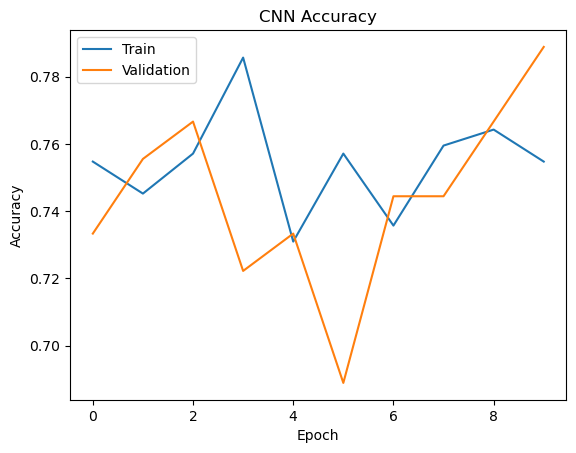

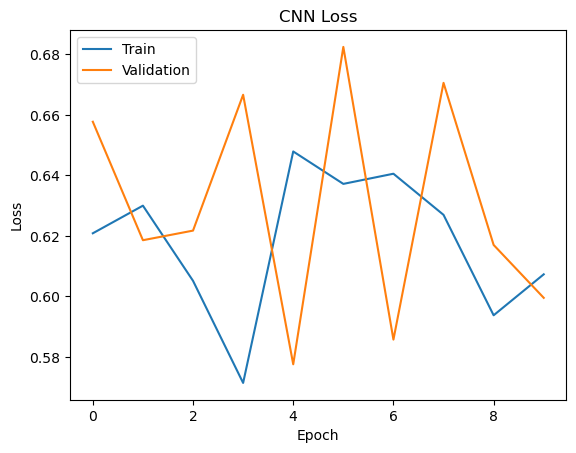

In [22]:
# =========================================================
# GRAFIK ACCURACY
# =========================================================

plt.plot(history_cnn.history['accuracy'])
plt.plot(history_cnn.history['val_accuracy'])

plt.title('CNN Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train', 'Validation'])

plt.show()

# =========================================================
# GRAFIK LOSS
# =========================================================

plt.plot(history_cnn.history['loss'])
plt.plot(history_cnn.history['val_loss'])

plt.title('CNN Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Train', 'Validation'])

plt.show()

Pada grafik CNN, garis biru dan oranye sama-sama naik ke atas dengan kompak. Ini membuktikan bahwa CNN tidak sekadar menghafal, tetapi benar-benar "belajar" mengenali bentuk dan tekstur sampah. Alhasil, model CNN tetap bisa menebak dengan akurat (mencapai sekitar 80% ke atas) meskipun diuji menggunakan gambar sampah yang benar-benar baru.

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step


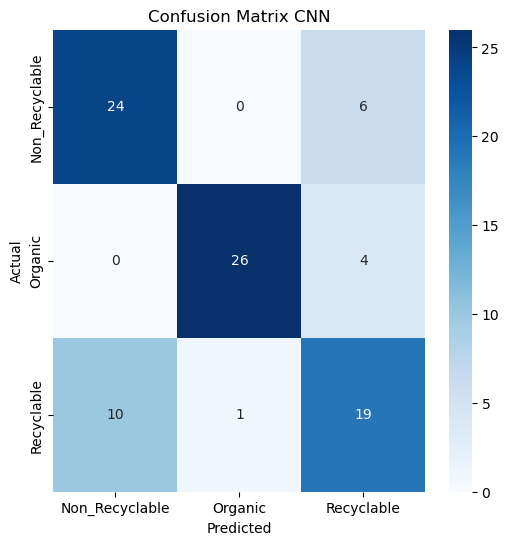


Classification Report:

                precision    recall  f1-score   support

Non_Recyclable       0.71      0.80      0.75        30
       Organic       0.96      0.87      0.91        30
    Recyclable       0.66      0.63      0.64        30

      accuracy                           0.77        90
     macro avg       0.77      0.77      0.77        90
  weighted avg       0.77      0.77      0.77        90



In [23]:
# =========================================================
# CONFUSION MATRIX CNN
# =========================================================

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# Prediksi test
predictions = cnn_model.predict(test_generator)

predicted_classes = np.argmax(
    predictions,
    axis=1
)

true_classes = test_generator.classes

class_labels = list(
    test_generator.class_indices.keys()
)

# Confusion matrix
cm = confusion_matrix(
    true_classes,
    predicted_classes
)

# Visualisasi
plt.figure(figsize=(6,6))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues',

    xticklabels=class_labels,

    yticklabels=class_labels
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix CNN")

plt.show()

# Classification report
print("\nClassification Report:\n")

print(

    classification_report(

        true_classes,

        predicted_classes,

        target_names=class_labels
    )
)

Dapat dilihat pada hasil classification report di atas bahwa model CNN memperoleh accuracy sebesar 77% pada data testing. Nilai precision, recall, dan f1-score digunakan untuk melihat performa model pada masing-masing kelas.

Pada kelas Organic, model memiliki performa terbaik dengan nilai precision sebesar 0,96 dan f1-score sebesar 0,91. Hal ini menunjukkan bahwa model mampu mengenali sampah organik dengan sangat baik. Sementara itu, pada kelas Non_Recyclable, model memperoleh f1-score sebesar 0,75 yang menunjukkan performa cukup baik.

Namun, pada kelas Recyclable, model masih mengalami beberapa kesalahan klasifikasi dengan nilai f1-score sebesar 0,64. Hal ini menunjukkan bahwa model masih cukup kesulitan membedakan sampah recyclable dengan kelas lainnya. Secara keseluruhan, model CNN sudah mampu melakukan klasifikasi gambar dengan cukup baik karena memperoleh accuracy sebesar 77% pada data testing.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
Prediksi CNN : Recyclable


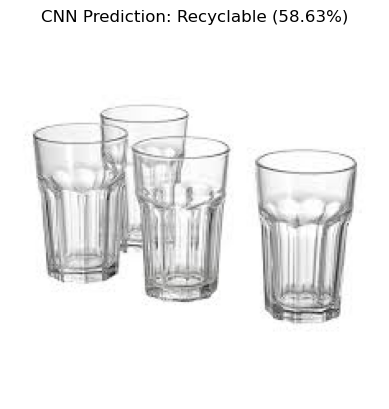

In [26]:
# =========================================================
# PREDIKSI DATA BARU CNN
# =========================================================

img_path = "gelaskaca.jpg"

# Load image
img = load_img(

    img_path,

    target_size=(224,224)
)

# Image to array
img_array = img_to_array(img)

# Normalisasi
img_array = img_array / 255.0

# Tambah dimensi
img_array = np.expand_dims(
    img_array,
    axis=0
)

# Prediksi
prediction = cnn_model.predict(
    img_array
)

# Nama kelas
class_names = [

    "Non-Recyclable",

    "Organic",

    "Recyclable"
]

# Hasil prediksi
predicted_class = class_names[
    np.argmax(prediction)
]

confidence = np.max(prediction) * 100

print("Prediksi CNN :",
      predicted_class)


# Tampilkan gambar
plt.imshow(load_img(img_path))

plt.title(
    f"CNN Prediction: {predicted_class} ({confidence:.2f}%)"
)

plt.axis("off")

plt.show()

Berbeda dengan model ANN yang salah mengenali objek, model CNN berhasil memprediksi gambar gelas kaca dengan tepat sebagai kelas 'Recyclable'. Meskipun probabilitas model berada di angka 58,63% yang mana sangat wajar karena sifat transparan dan pantulan cahaya pada material kaca cukup menantang secara visual, hasil ini tetap membuktikan bahwa arsitektur CNN jauh lebih adaptif dan andal dalam mengenali fitur spasial citra dibandingkan ANN.

## Kesimpulan

1. Perbandingan kinerja ANN dan CNN

- Akurasi
    - ANN: sekitar `57.78%` pada data test.
    - CNN: sekitar `76.67%` pada data test.
    - Kesimpulan: CNN lebih akurat dalam klasifikasi tiga kelas sampah.

- Waktu pelatihan
    - ANN memiliki arsitektur lebih sederhana sehingga cenderung lebih cepat dilatih.
    - CNN lebih lambat karena memiliki lebih banyak lapisan konvolusi dan parameter.
    - Catatan: CNN menggunakan `EarlyStopping`, sehingga pelatihan bisa berhenti lebih cepat jika tidak ada peningkatan validasi.

- Kompleksitas model
    - ANN: sekitar 3,16 juta parameter.
    - CNN: sekitar 11,17 juta parameter.
    - Kesimpulan: CNN lebih kompleks, tetapi kompleksitas ini membantu menangkap fitur spasial dalam gambar.

- Kemampuan generalisasi terhadap data baru
    - ANN cenderung overfitting: akurasi training tinggi, tetapi validasi dan test rendah.
    - CNN menunjukkan generalisasi lebih baik dan berhasil memprediksi gambar baru (`gelaskaca.jpg`) secara lebih benar.
    - ANN salah memprediksi `gelaskaca.jpg` sebagai Non-Recyclable, sedangkan CNN memprediksi benar sebagai Recyclable.

2. Kelebihan dan kekurangan

- ANN
    - Kelebihan:
        - Sederhana dan cepat dilatih.
        - Cocok untuk data yang tidak memiliki hubungan spasial kompleks.
    - Kekurangan:
        - Tidak efektif untuk citra karena tidak menangkap pola spasial antar piksel.
        - Mudah overfitting dan kurang akurat untuk klasifikasi gambar.

- CNN
    - Kelebihan:
        - Mampu mengekstraksi fitur spasial dari gambar.
        - Lebih akurat dan lebih baik dalam generalisasi pada data baru.
        - Lebih cocok untuk masalah klasifikasi citra.
    - Kekurangan:
        - Lebih kompleks dan memerlukan waktu pelatihan lebih lama.
        - Membutuhkan sumber daya komputasi lebih besar.